# Convulational Neural Network for CIFAR10 Dataset

## Overview

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

Here are the classes in the dataset, as well as 10 random images from each:
- airplane
- automobile				
- bird										
- cat										
- deer										
- dog										
- frog										
- horse										
- ship										
- truck

The classes are completely mutually exclusive. There is no overlap between automobiles and trucks. "Automobile" includes sedans, SUVs, things of that sort. "Truck" includes only big trucks. Neither includes pickup trucks. We can use it to demonstrate how a CNN can learn to recognize objects in images:

1. Task & dataset
2. Data cleaning & preparation
3. Exploratory Data Analysis (EDA)
4. Train/validation/test split
5. Model training (forward pass, backprop, optimiser)
6. Evaluation metrics & loss curves
7. Error analysis
8. Pros, cons & real-world examples

## Setup and Imports

In [58]:
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)

np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.22.0-rc0


## 1. Load the CIFAR10 dataset

The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 5000 images from each class.

In [59]:
data_dir = Path("data")

def load_batch(filename):
    with open(data_dir / filename, "rb") as f:
        batch = pickle.load(f, encoding="bytes")
    images = batch[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.asarray(batch[b"labels"]).ravel()
    return images, labels

train_batches = [load_batch(f"data_batch_{i}") for i in range(1, 6)]
X_train = np.concatenate([x for x, _ in train_batches])
y_train = np.concatenate([y for _, y in train_batches])
X_test, y_test = load_batch("test_batch")

print('X_train shape:', X_train.shape)  # (60000, 28, 28)
print('y_train shape:', y_train.shape)
print('X_test  shape:', X_test.shape)
print('y_test  shape:', y_test.shape)
print('Pixel value range:', X_train.min(), '-', X_train.max())
print('Unique labels:', np.unique(y_train))

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)
X_test  shape: (10000, 32, 32, 3)
y_test  shape: (10000,)
Pixel value range: 0 - 255
Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [60]:
class_names = [
    "Airplane", "Automobile", "Bird", 
    "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"
]
print(list(zip(np.unique(y_train), class_names)))

[(np.int64(0), 'Airplane'), (np.int64(1), 'Automobile'), (np.int64(2), 'Bird'), (np.int64(3), 'Cat'), (np.int64(4), 'Deer'), (np.int64(5), 'Dog'), (np.int64(6), 'Frog'), (np.int64(7), 'Horse'), (np.int64(8), 'Ship'), (np.int64(9), 'Truck')]


## 2. Data Cleaning and Preprocessing

In [61]:
# check for missing values (Nan or out of range values) -sanity check
print('Nan in X_train: ', np.isnan(X_train).any())
print('Nan in y_train: ', np.isnan(y_train).any())

Nan in X_train:  False
Nan in y_train:  False


In [62]:
# normalize pixel values to be between 0 and 1 for stable gradient descent
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0




print('X_train shape after prep:', X_train.shape)
print('X_test shape after prep :', X_test.shape)
print('New pixel range:', X_train.min(), '-', X_train.max())

X_train shape after prep: (50000, 32, 32, 3)
X_test shape after prep : (10000, 32, 32, 3)
New pixel range: 0.0 - 1.0


## 3. Exploratory Data Analysis

In [63]:
train_counts = pd.Series(np.asarray(y_train).ravel()).value_counts()
test_counts = pd.Series(np.asarray(y_test).ravel()).value_counts()

balance_df = pd.DataFrame({
    "Class": class_names,
    "Train": train_counts.reindex(range(len(class_names)), fill_value=0).to_numpy(),
    "Test": test_counts.reindex(range(len(class_names)), fill_value=0).to_numpy()
})
balance_df

,Class,Train,Test
0,Airplane,5000,1000
1,Automobile,5000,1000
2,Bird,5000,1000
3,Cat,5000,1000
4,Deer,5000,1000
5,Dog,5000,1000
6,Frog,5000,1000
7,Horse,5000,1000
8,Ship,5000,1000
9,Truck,5000,1000


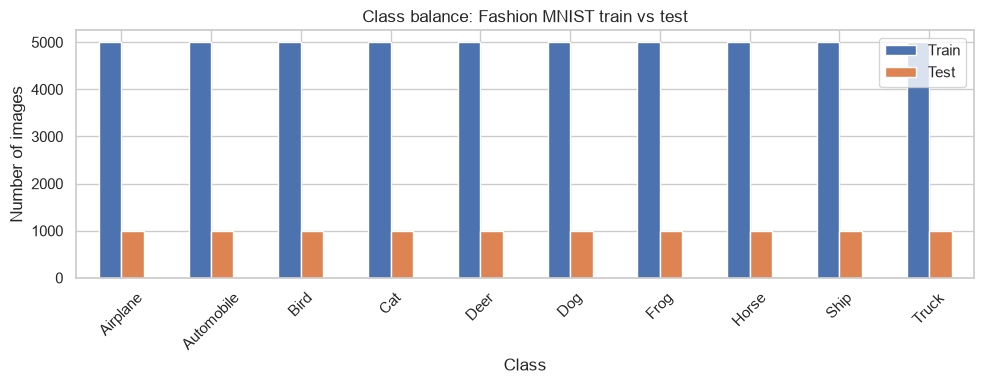

In [64]:
# plot on class counts
balance_df.plot(x='Class', y=['Train', 'Test'], kind='bar', figsize=(10, 4), rot=45)
plt.title('Class balance: Fashion MNIST train vs test')
plt.ylabel('Number of images')
plt.tight_layout()
plt.show()

### Sanity-check labels by sampling images

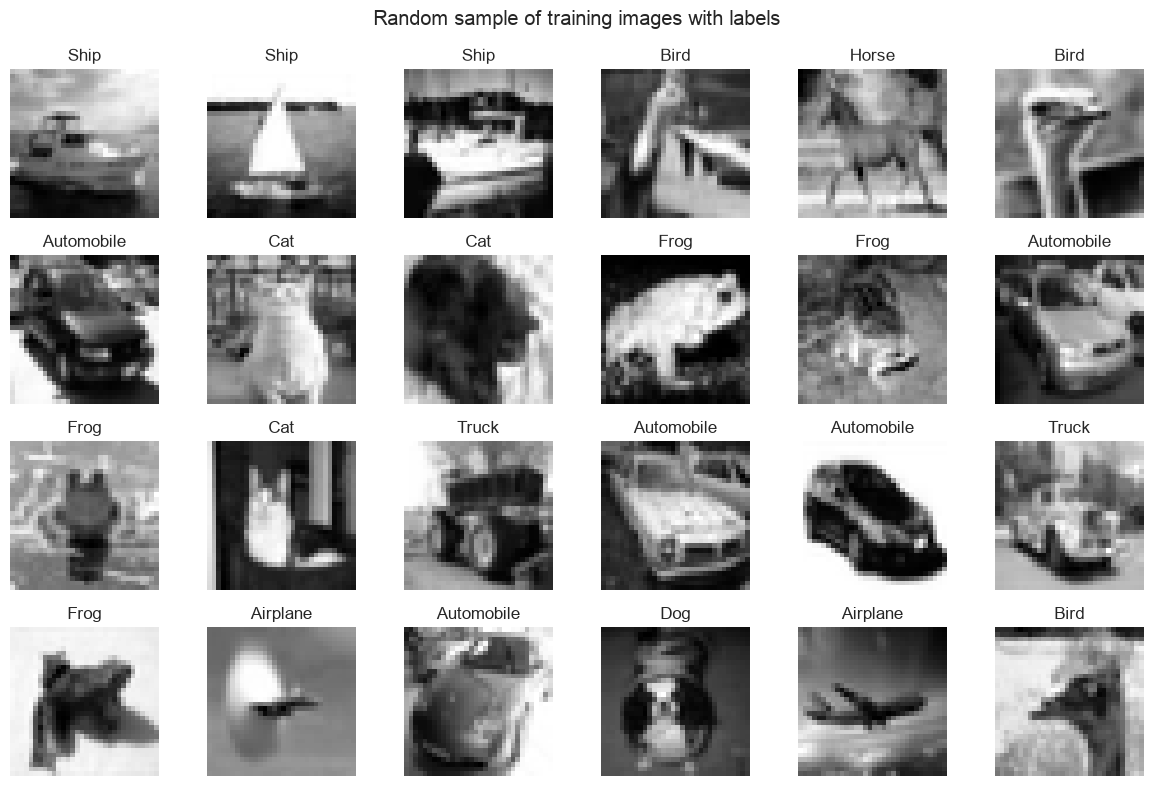

In [65]:
fig, axes = plt.subplots(4, 6, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(X_train))
    ax.imshow(X_train[idx, :, :, 0], cmap='gray')
    label_index = int(np.asarray(y_train).ravel()[idx])
    ax.set_title(class_names[label_index])
    ax.axis('off')
plt.suptitle('Random sample of training images with labels')
plt.tight_layout()
plt.show()

## 4. Train/Validation/Test split

In [66]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

print('Train:', X_train.shape)
print('Val  :', X_val.shape)
print('Test :', X_test.shape)

Train: (40000, 32, 32, 3)
Val  : (10000, 32, 32, 3)
Test : (10000, 32, 32, 3)


### Data Augmentation

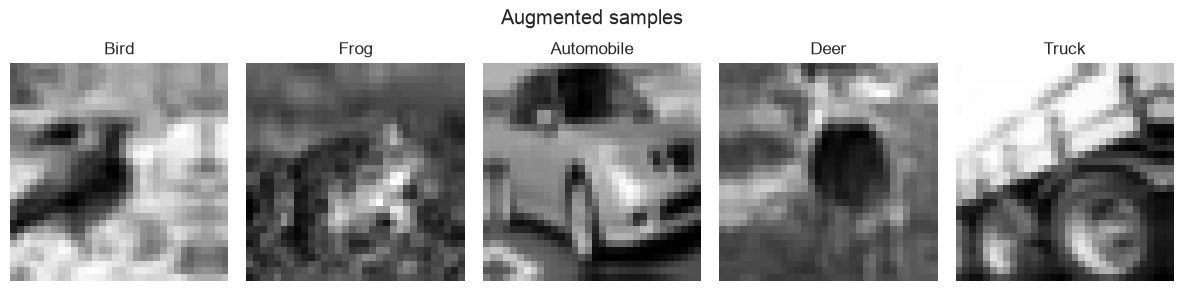

In [67]:
data_augmentation = keras.Sequential([
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomFlip('horizontal'),
], name='data_augmentation')

# visualize the augmented images
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
example = X_train[5:10]
aug = data_augmentation(example, training=True)
for i, ax in enumerate(axes.flat):
    ax.imshow(aug[i, :, :, 0].numpy(), cmap='gray')
    ax.axis('off')
    ax.set_title(class_names[int(np.asarray(y_train).ravel()[5 + i])])
plt.suptitle('Augmented samples')
plt.tight_layout()
plt.show()

## 5. Model Training (CNN)

In [68]:
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    
    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.25),

    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
], name='cifar10_cnn')

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,169,130 (8.27 MB)

 Trainable params: 2,168,746 (8.27 MB)

 Non-trainable params: 384 (1.50 KB)

In [69]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),
]

EPOCHS = 30
BATCH_SIZE = 128

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 111s 340ms/step - accuracy: 0.3760 - loss: 1.8207 - val_accuracy: 0.2213 - val_loss: 2.8322 - learning_rate: 0.0010
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 136s 335ms/step - accuracy: 0.4957 - loss: 1.3961 - val_accuracy: 0.6016 - val_loss: 1.1197 - learning_rate: 0.0010
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 104s 332ms/step - accuracy: 0.5667 - loss: 1.2219 - val_accuracy: 0.5616 - val_loss: 1.3354 - learning_rate: 0.0010
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 311ms/step - accuracy: 0.6050 - loss: 1.1190 - val_accuracy: 0.6505 - val_loss: 1.0005 - learning_rate: 0.0010
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 289ms/step - accuracy: 0.6347 - loss: 1.0397 - val_accuracy: 0.6847 - val_loss: 0.9020 - learning_rate: 0.0010
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 106s 339ms/step - accuracy: 0.6542 - loss: 0.9891 - val_accuracy: 0.7005 - val_loss: 0.8668 - learning_rate: 0.0010
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 120s 383ms/step - accuracy

## 6. Evaluation Metrics & Loss Curves

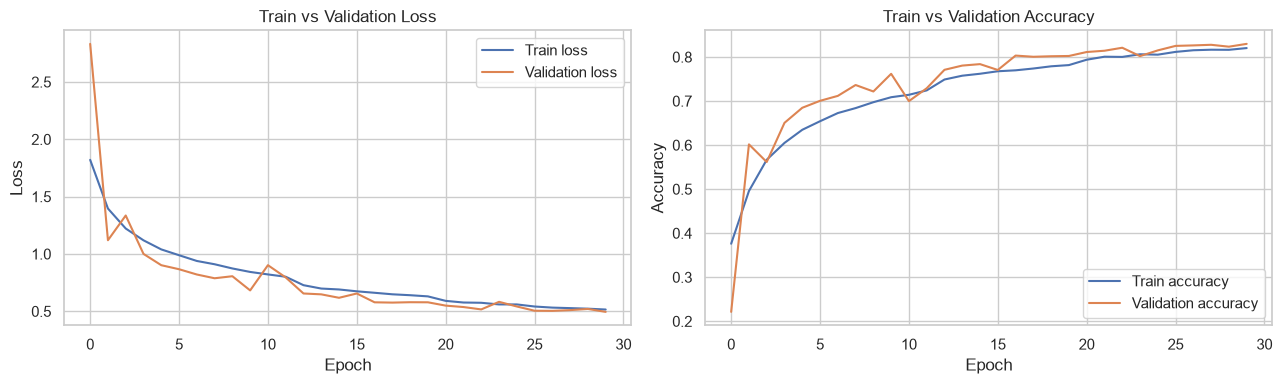

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'], label='Train loss')
axes[0].plot(history.history['val_loss'], label='Validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train vs Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Train vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Evaluate on the held-out test set

In [71]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

Test loss: 0.5255
Test accuracy: 0.8243


In [72]:
y_pred = model.predict(X_test, verbose=0)
y_pred_class = np.argmax(y_pred, axis=1)

print('Accuracy :', accuracy_score(y_test, y_pred_class))
print('Precision:', precision_score(y_test, y_pred_class, average='weighted'))
print('Recall   :', recall_score(y_test, y_pred_class, average='weighted'))
print('F1       :', f1_score(y_test, y_pred_class, average='weighted'))
# ROC-AUC computed one-vs-rest over the 10 classes
y_test_onehot = keras.utils.to_categorical(y_test, 10)
print('ROC-AUC  :', roc_auc_score(y_test_onehot, y_pred, average='weighted', multi_class='ovr'))

Accuracy : 0.8243
Precision: 0.8270254996154341
Recall   : 0.8243
F1       : 0.8217394000995768
ROC-AUC  : 0.9834097055555554


In [73]:
print(classification_report(y_test, y_pred_class, target_names=class_names))

              precision    recall  f1-score   support

    Airplane       0.81      0.87      0.84      1000
  Automobile       0.91      0.94      0.92      1000
        Bird       0.82      0.70      0.75      1000
         Cat       0.75      0.60      0.66      1000
        Deer       0.81      0.79      0.80      1000
         Dog       0.80      0.71      0.75      1000
        Frog       0.70      0.95      0.80      1000
       Horse       0.89      0.87      0.88      1000
        Ship       0.93      0.90      0.91      1000
       Truck       0.86      0.93      0.89      1000

    accuracy                           0.82     10000
   macro avg       0.83      0.82      0.82     10000
weighted avg       0.83      0.82      0.82     10000



### Confusion Matrix

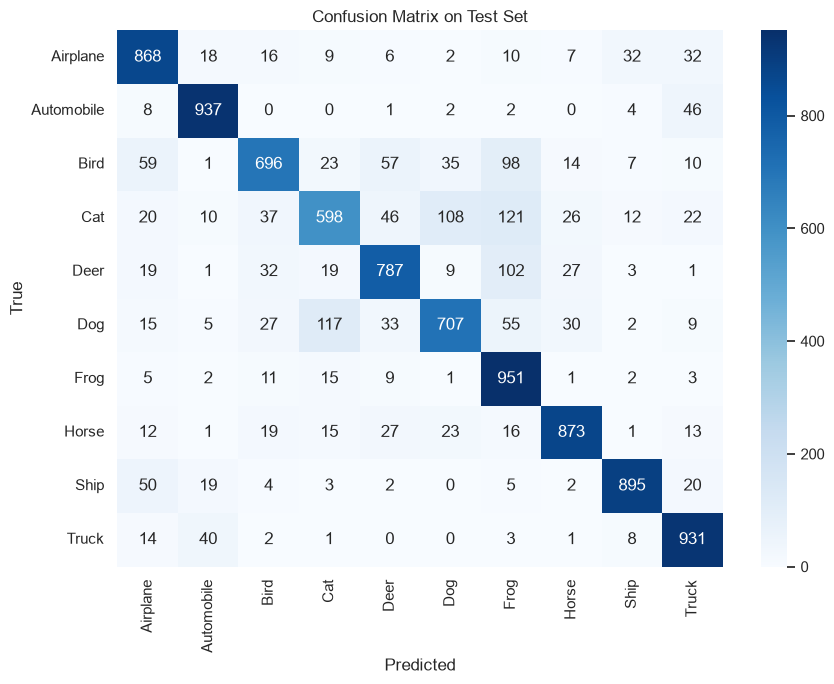

In [74]:
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## 7. Error Analysis

Number of misclassified examples: 1757 out of 10000


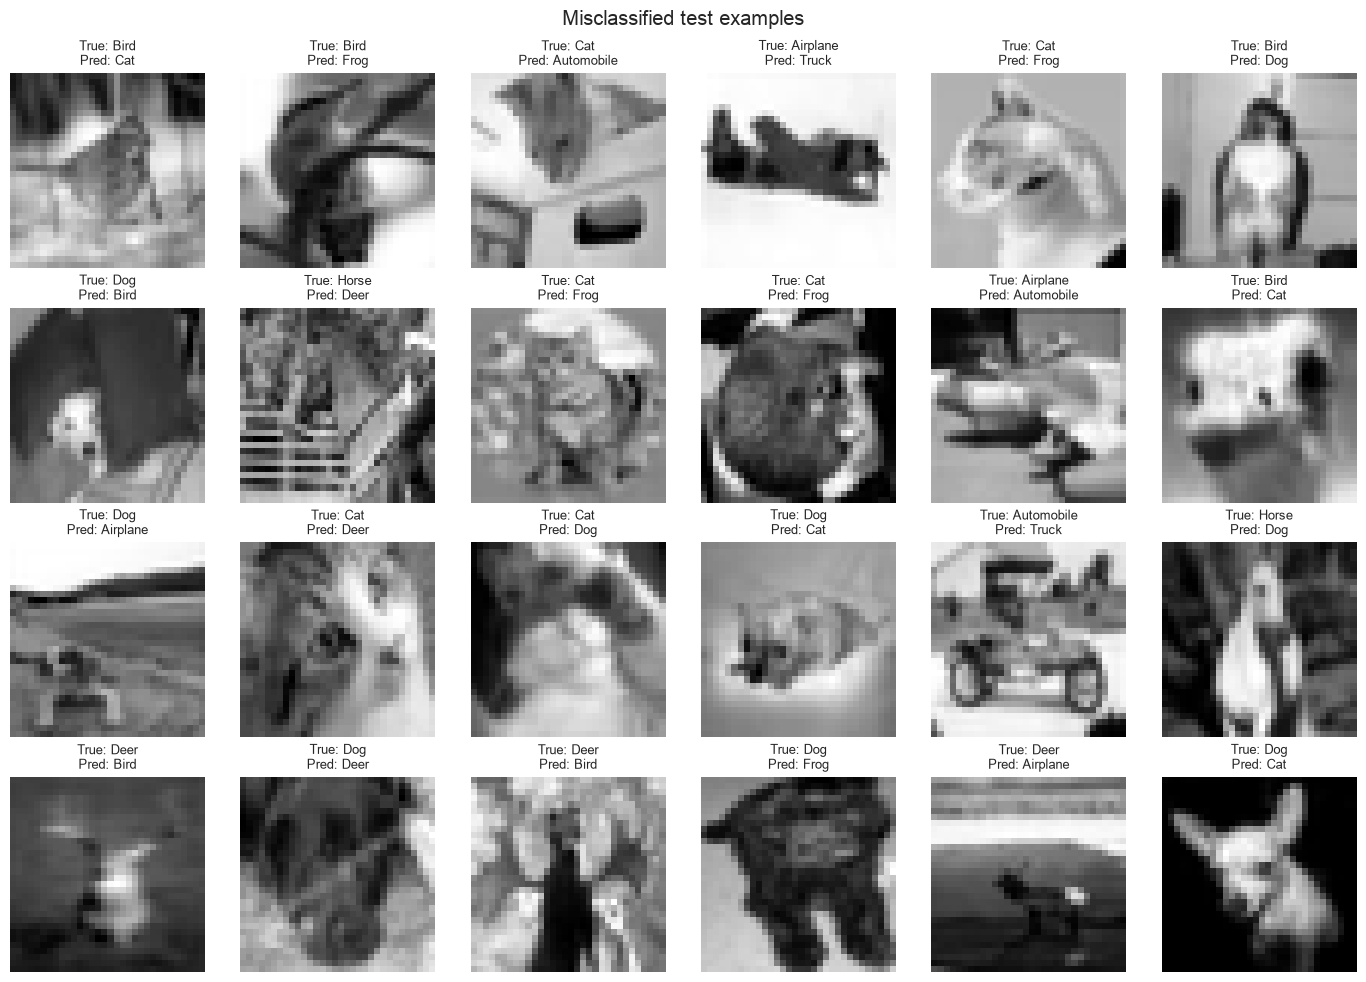

In [75]:
misclassified = np.where(y_pred_class != y_test)[0]
print(f'Number of misclassified examples: {len(misclassified)} out of {len(y_test)}')

fig, axes = plt.subplots(4, 6, figsize=(14, 10))
sample = np.random.choice(misclassified, size=24, replace=False)
for ax, idx in zip(axes.flat, sample):
    ax.imshow(X_test[idx, :, :, 0], cmap='gray')
    ax.set_title(f'True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred_class[idx]]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Misclassified test examples')
plt.tight_layout()
plt.show()

### Which confusion pairs cause the errors

Total misclassified: 1757

Top 8 confusion pairs:
  Cat          -> Frog          121
  Dog          -> Cat           117
  Cat          -> Dog           108
  Deer         -> Frog          102
  Bird         -> Frog           98
  Bird         -> Airplane       59
  Bird         -> Deer           57
  Dog          -> Frog           55


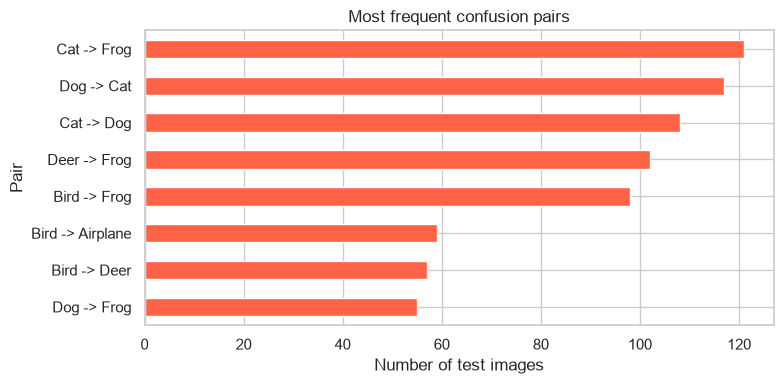

In [76]:
# Rank every true -> pred confusion pair by how often it occurs
cm = confusion_matrix(y_test, y_pred_class)
pairs = pd.DataFrame(
    [{'True': class_names[t], 'Pred': class_names[p], 'Count': cm[t, p]}
     for t in range(10) for p in range(10) if t != p and cm[t, p] > 0]
).sort_values('Count', ascending=False).reset_index(drop=True)

print(f'Total misclassified: {cm.sum() - np.trace(cm)}')
print('\nTop 8 confusion pairs:')
for _, r in pairs.head(8).iterrows():
    print(f'  {r["True"]:12s} -> {r["Pred"]:12s}  {r["Count"]:3d}')

plot_df = pairs.head(8).copy()
plot_df['Pair'] = plot_df['True'] + ' -> ' + plot_df['Pred']
plot_df.plot(x='Pair', y='Count', kind='barh', figsize=(8, 4), legend=False, color='tomato')
plt.xlabel('Number of test images')
plt.title('Most frequent confusion pairs')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Which classes produce the errors

Errors by true class:
  Airplane    : 132  (7.5% of all errors)
  Automobile  :  63  (3.6% of all errors)
  Bird        : 304  (17.3% of all errors)
  Cat         : 402  (22.9% of all errors)
  Deer        : 213  (12.1% of all errors)
  Dog         : 293  (16.7% of all errors)
  Frog        :  49  (2.8% of all errors)
  Horse       : 127  (7.2% of all errors)
  Ship        : 105  (6.0% of all errors)
  Truck       :  69  (3.9% of all errors)


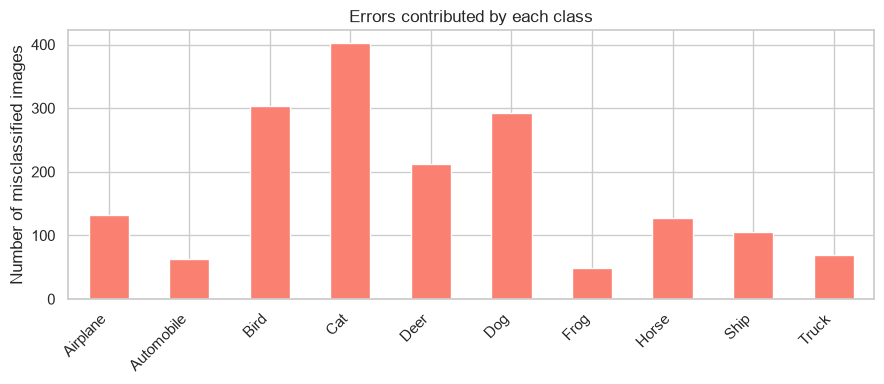

In [77]:
# How many true images of each class the model got wrong
wrong = y_pred_class != y_test
errors_by_class = pd.Series(y_test[wrong]).value_counts().sort_index()
errors_by_class.index = [class_names[i] for i in errors_by_class.index]
errors_by_class = errors_by_class.reindex(class_names, fill_value=0)

share = (100 * errors_by_class / errors_by_class.sum()).round(1)
print('Errors by true class:')
for cls, n in errors_by_class.items():
    print(f'  {cls:12s}: {n:3d}  ({share[cls]}% of all errors)')

errors_by_class.plot(kind='bar', figsize=(9, 4), color='salmon', rot=45)
plt.ylabel('Number of misclassified images')
plt.title('Errors contributed by each class')
plt.xticks(ha='right')
plt.tight_layout()
plt.show()

### How confident is the model when its wrong

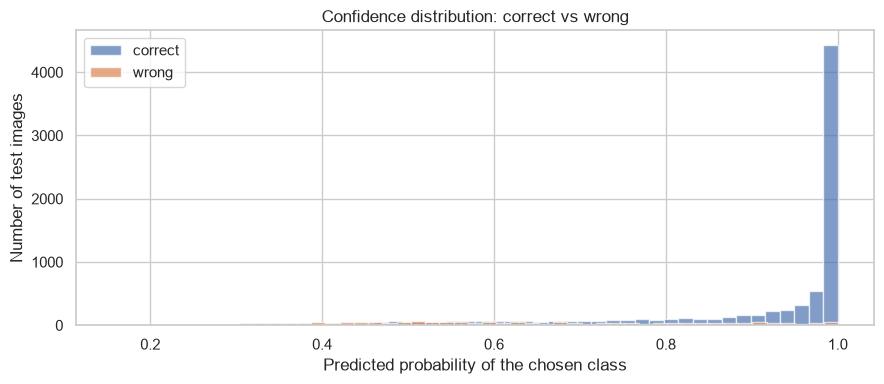

Wrong predictions with confidence >= 0.90 : 240
Wrong predictions with confidence <  0.60 : 897
Mean confidence - correct: 0.897 | wrong: 0.615


In [78]:
# Confidence of correct vs wrong predictions
confidence = y_pred.max(axis=1)
correct = y_pred_class == y_test

plt.figure(figsize=(9, 4))
plt.hist(confidence[correct], bins=50, alpha=0.7, label='correct')
plt.hist(confidence[~correct], bins=50, alpha=0.7, label='wrong')
plt.xlabel('Predicted probability of the chosen class')
plt.ylabel('Number of test images')
plt.title('Confidence distribution: correct vs wrong')
plt.legend()
plt.tight_layout()
plt.show()

high_conf_wrong = (~correct) & (confidence >= 0.90)
print(f'Wrong predictions with confidence >= 0.90 : {high_conf_wrong.sum()}')
print(f'Wrong predictions with confidence <  0.60 : {((~correct) & (confidence < 0.60)).sum()}')
print(f'Mean confidence - correct: {confidence[correct].mean():.3f} | wrong: {confidence[~correct].mean():.3f}')

### The model's most confident mistakes

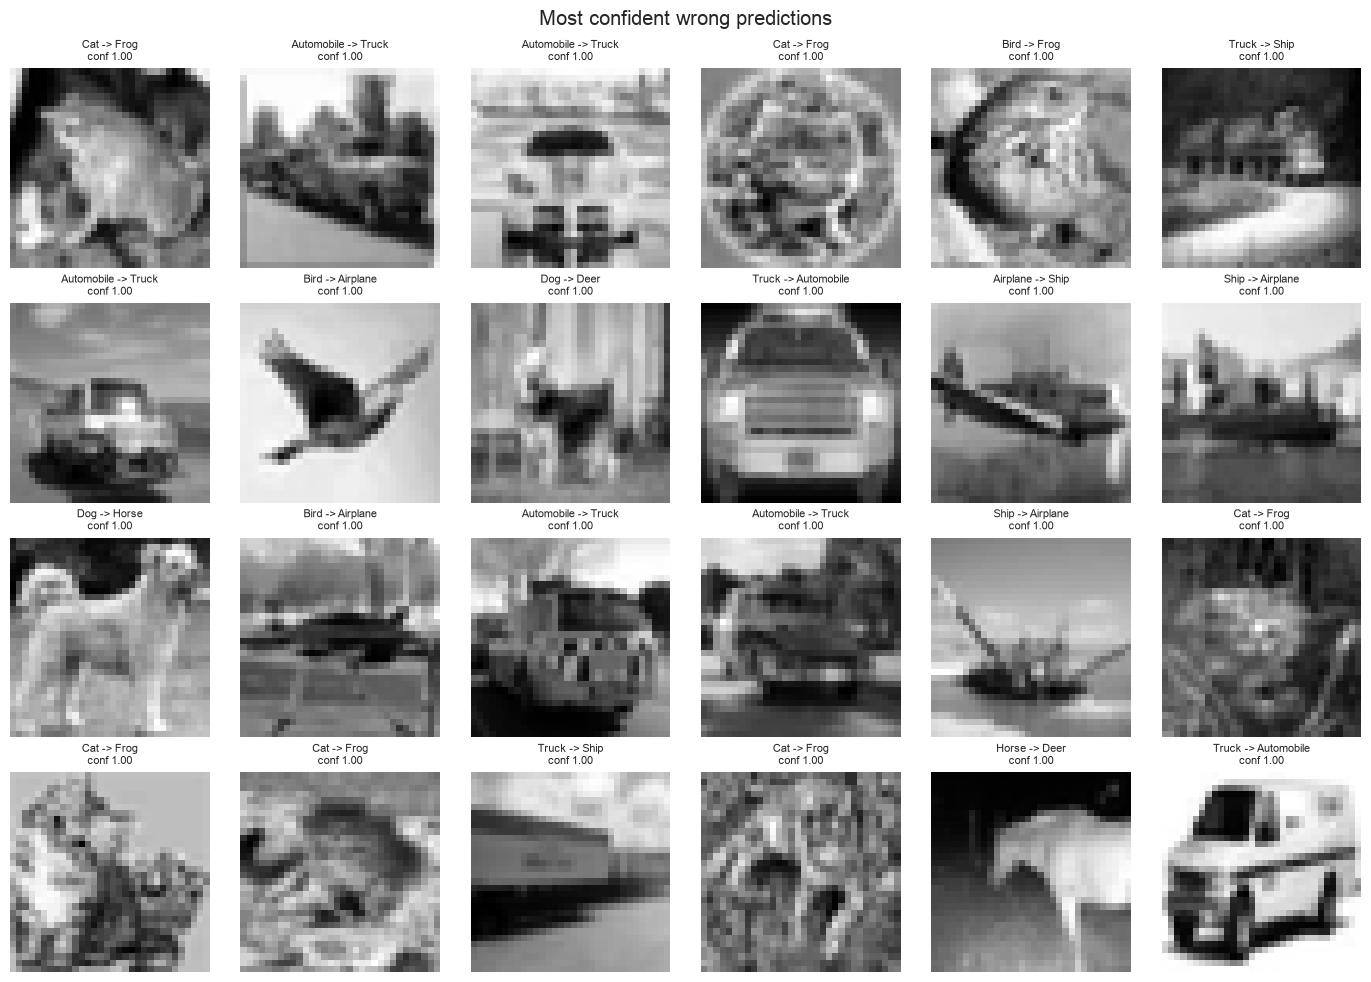

In [79]:
# The wrong predictions the model was most sure about
worst = np.where(~correct)[0]
worst = worst[np.argsort(-confidence[worst])][:24]

fig, axes = plt.subplots(4, 6, figsize=(14, 10))
for ax, idx in zip(axes.flat, worst):
    ax.imshow(X_test[idx, :, :, 0], cmap='gray')
    ax.set_title(f'{class_names[y_test[idx]]} -> {class_names[y_pred_class[idx]]}\nconf {confidence[idx]:.2f}', fontsize=8)
    ax.axis('off')
plt.suptitle('Most confident wrong predictions')
plt.tight_layout()
plt.show()

### Reducing the errors

In [80]:
# Test-Time Augmentation: average predictions over small variations of each
# image. No retraining needed - fixes borderline, low-confidence mistakes.
def tta_predict(X, model=model):
    variants = [
        X,                            # original
        X[:, :, ::-1, :].copy(),      # horizontal flip
        np.roll(X, 1, axis=2),        # shift 1px right
        np.roll(X, -1, axis=2),       # shift 1px left
        np.roll(X, 1, axis=1),        # shift 1px down
        np.roll(X, -1, axis=1),       # shift 1px up
    ]
    probs = np.zeros((len(X), 10), dtype='float32')
    for v in variants:
        probs += model.predict(v, verbose=0)
    return probs / len(variants)

y_pred_tta = tta_predict(X_test)
tta_class = np.argmax(y_pred_tta, axis=1)

before = y_pred_class != y_test
after = tta_class != y_test

print(f'Accuracy before TTA: {accuracy_score(y_test, y_pred_class):.4f}')
print(f'Accuracy after  TTA: {accuracy_score(y_test, tta_class):.4f}')
print(f'Errors fixed by TTA : {(before & ~after).sum()}')
print(f'Errors introduced   : {(~before & after).sum()}')
print(f'Net change          : {before.sum() - after.sum():+d} errors')

Accuracy before TTA: 0.8243
Accuracy after  TTA: 0.8306
Errors fixed by TTA : 161
Errors introduced   : 98
Net change          : +63 errors


In [81]:
# Backup the weights first so you can roll back if it does not help.
weights_before = model.get_weights()
acc_before = accuracy_score(y_test, y_pred_class)

class_weight = {i: 1.0 for i in range(10)}
class_weight[6] = 2.0            # Shirt - worst F1 (0.79), ~30% of all errors

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy'],
)

history_ft = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1,
)

y_pred_ft = model.predict(X_test, verbose=0)
ft_class = np.argmax(y_pred_ft, axis=1)
print(f'Test accuracy before fine-tuning: {acc_before:.4f}')
print(f'Test accuracy after  fine-tuning: {accuracy_score(y_test, ft_class):.4f}')
print('Roll back with: model.set_weights(weights_before)')

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 195ms/step - accuracy: 0.8143 - loss: 1.2774 - val_accuracy: 0.8221 - val_loss: 1.1102
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 153ms/step - accuracy: 0.8058 - loss: 1.1982 - val_accuracy: 0.8219 - val_loss: 1.0776
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 151ms/step - accuracy: 0.8093 - loss: 1.1723 - val_accuracy: 0.8245 - val_loss: 1.0543
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 149ms/step - accuracy: 0.8107 - loss: 1.1545 - val_accuracy: 0.8253 - val_loss: 1.0370
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 150ms/step - accuracy: 0.8120 - loss: 1.1424 - val_accuracy: 0.8253 - val_loss: 1.0225
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 150ms/step - accuracy: 0.8147 - loss: 1.1305 - val_accuracy: 0.8198 - val_loss: 1.0234
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 165ms/step - accuracy: 0.8146 - loss: 1.1186 - val_accuracy: 0.8240 - val_loss: 1.0103
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 154ms/step - accuracy: 0.8204 - loss: 1

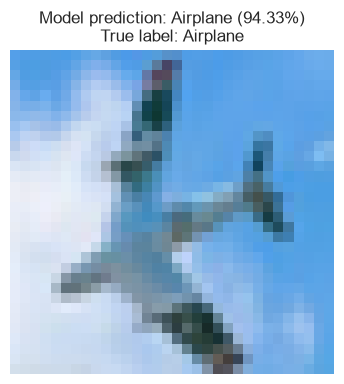

In [82]:
def predict_image(X, y_true=None, title='Model prediction'):
    pred = model.predict(X, verbose=0)
    pred_class = int(np.argmax(pred, axis=1)[0])
    confidence = float(np.max(pred))
    plt.figure(figsize=(4, 4))
    plt.imshow(X[0])
    label = f'{title}: {class_names[pred_class]} ({confidence:.2%})'
    if y_true is not None:
        label += f'\nTrue label: {class_names[int(np.asarray(y_true).ravel()[0])]}'
    plt.title(label)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    return pred_class, pred


# Test on a single random test image (model has never seen these examples during training)
idx = np.random.randint(0, len(X_test))
pred_class, pred = predict_image(X_test[idx:idx + 1], y_test[idx])

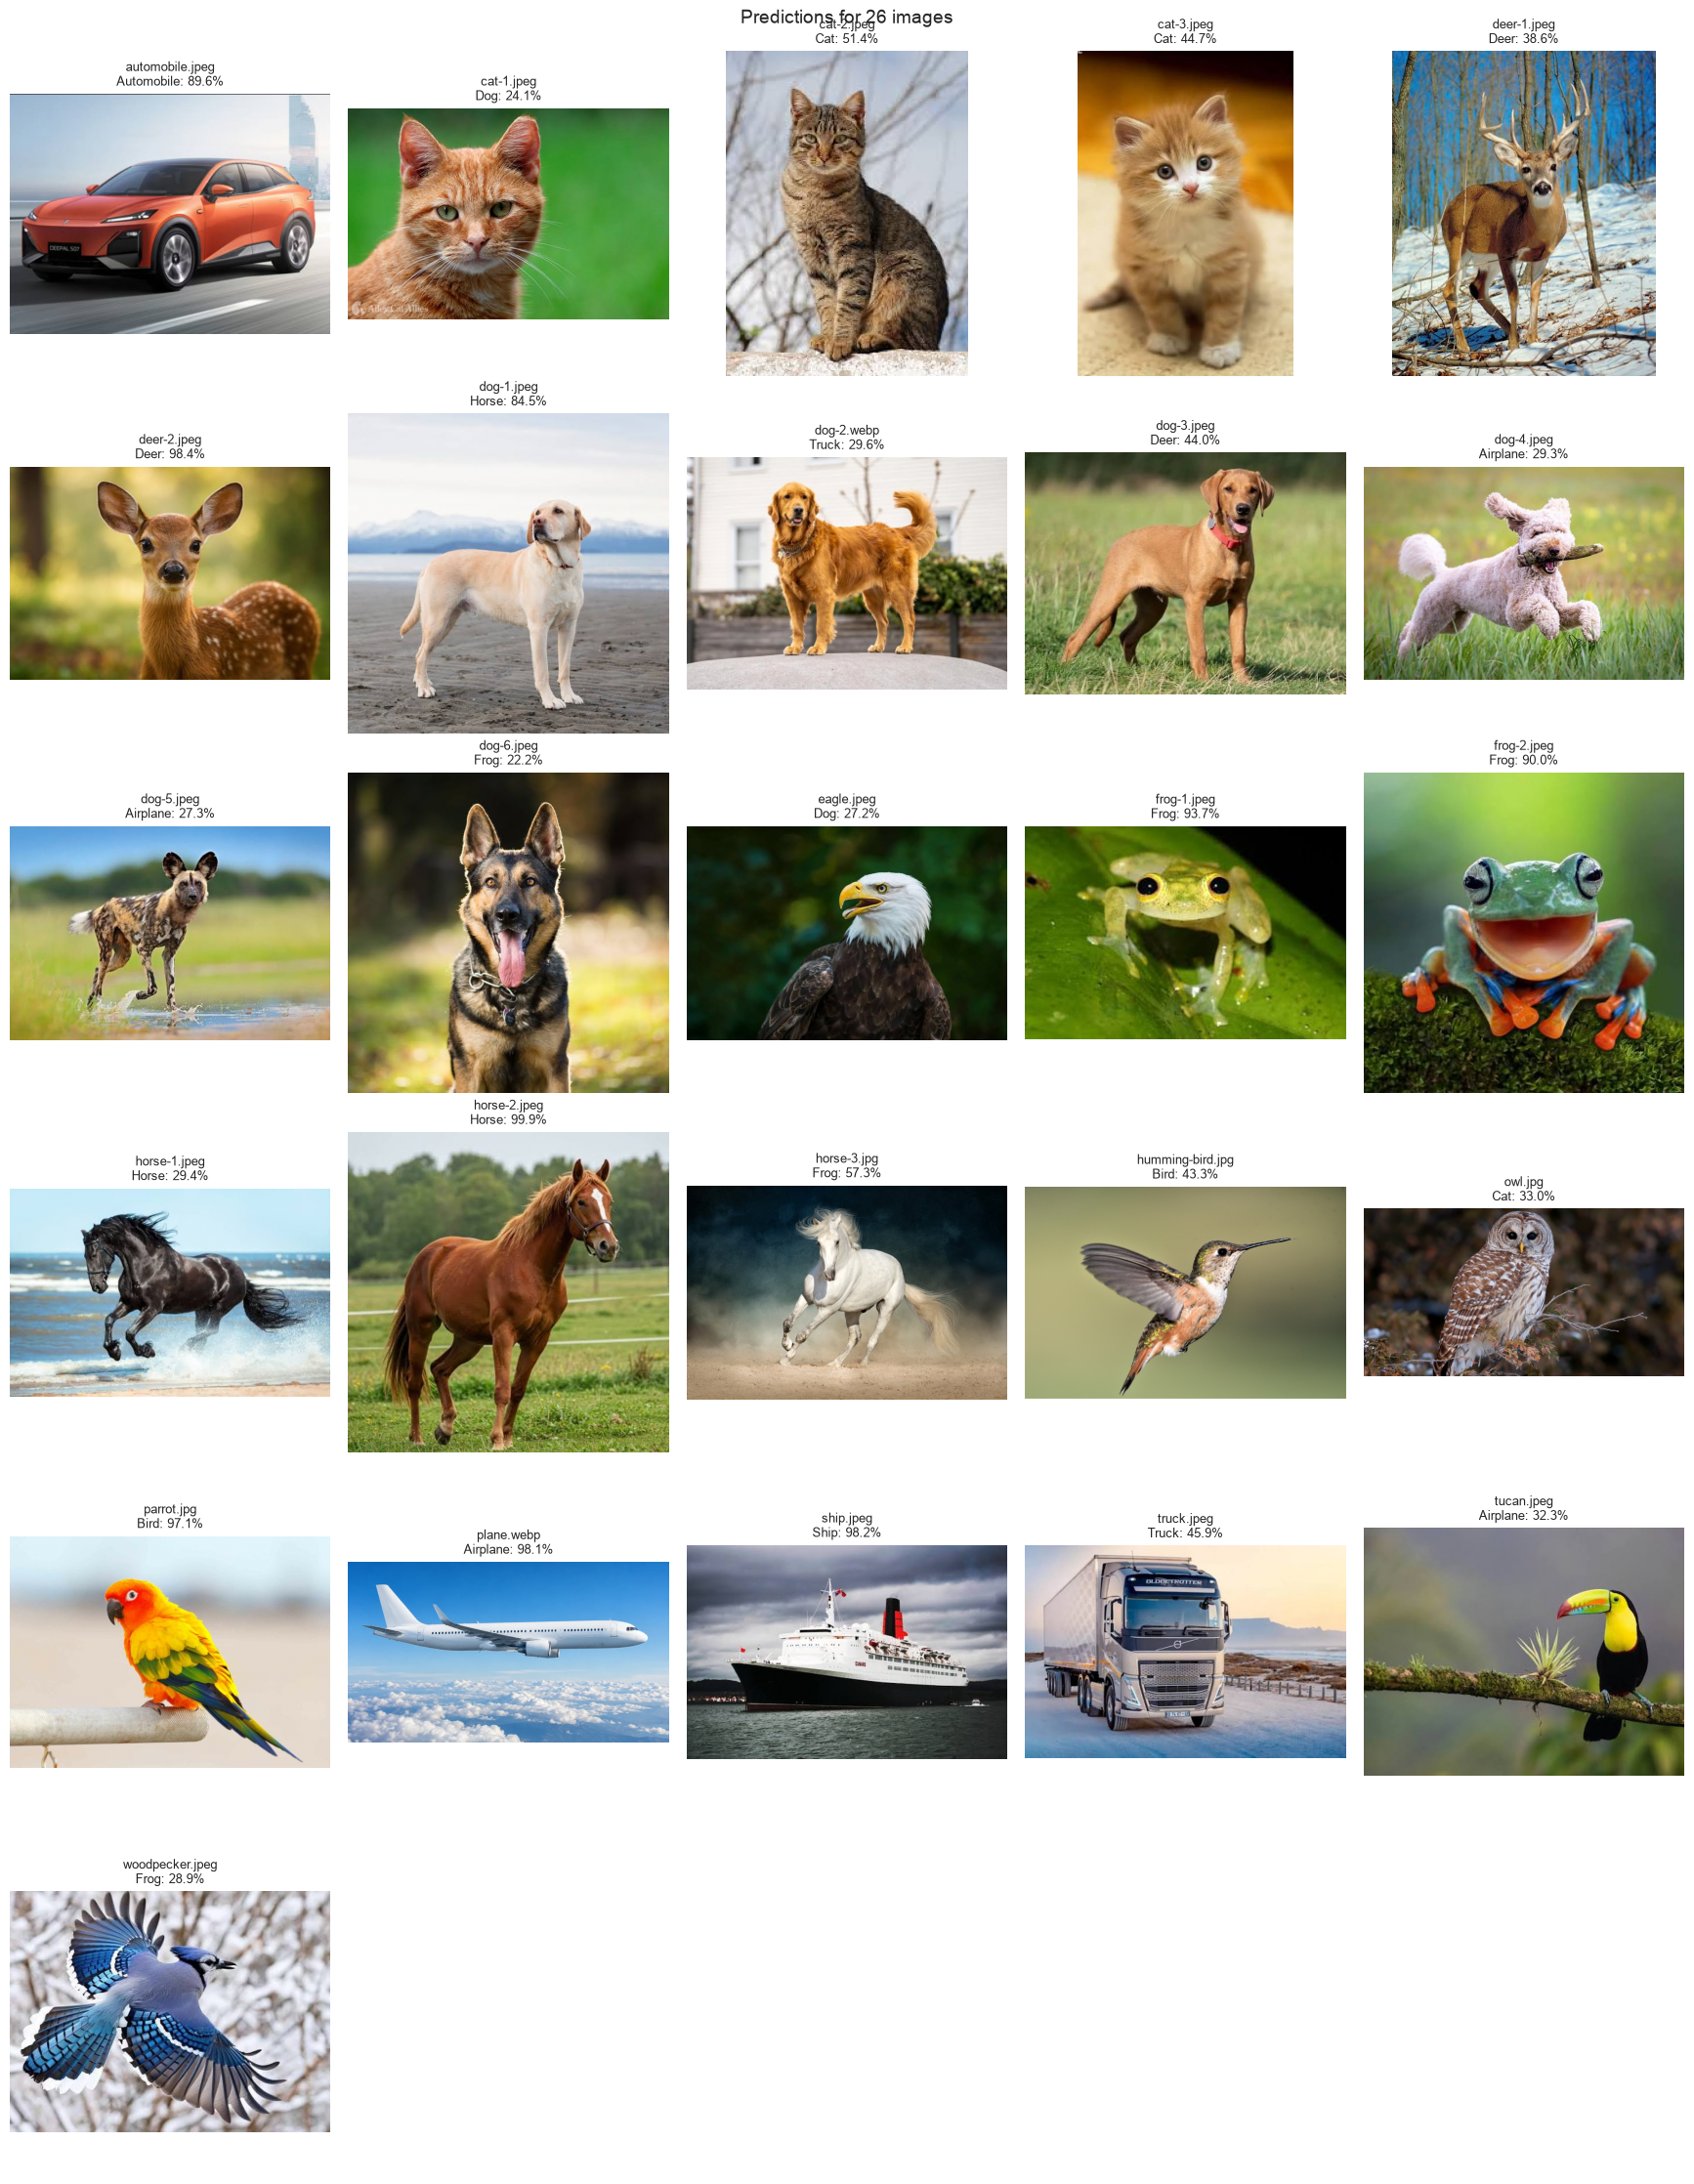

In [83]:
from PIL import Image

def preprocess_image(path):
    im = Image.open(path).convert('RGB')
    a = np.array(im)
    bg = np.median(a.reshape(-1, 3), axis=0).astype(int)
    mask = np.abs(a.astype(int) - bg).max(axis=2) > 25
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    if len(rows) and len(cols):
        im = im.crop((cols.min(), rows.min(), cols.max() + 1, rows.max() + 1))

    side = max(im.size)
    background = tuple(int(channel) for channel in bg)
    sq = Image.new('RGB', (side, side), background)
    sq.paste(im, ((side - im.width) // 2, (side - im.height) // 2))
    sq = sq.resize((32, 32), Image.Resampling.LANCZOS)
    return np.array(sq).astype('float32')[np.newaxis, ...] / 255.0


def predict_sample_folder(folder='samples', ncols=5):
    if ncols < 1:
        raise ValueError('ncols must be at least 1')
    extensions = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.gif'}
    paths = sorted(
        path for path in Path(folder).iterdir()
        if path.is_file() and path.suffix.lower() in extensions
    )
    if not paths:
        raise FileNotFoundError(f'No supported images found in {folder}')

    image_batch = np.concatenate([preprocess_image(path) for path in paths], axis=0)
    predictions = model.predict(image_batch, verbose=0)
    display_images = [np.array(Image.open(path).convert('RGB')) / 255.0 for path in paths]
    nrows = int(np.ceil(len(paths) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.5 * ncols, 3.8 * nrows), squeeze=False
    )

    for index, (ax, path, probabilities) in enumerate(zip(axes.flat, paths, predictions)):
        predicted_index = int(np.argmax(probabilities))
        confidence = probabilities[predicted_index]
        ax.imshow(display_images[index])
        ax.set_title(
            f'{path.name}\n{class_names[predicted_index]}: {confidence:.1%}',
            fontsize=9,
        )
        ax.axis('off')

    for ax in axes.flat[len(paths):]:
        ax.axis('off')
    fig.suptitle(f'Predictions for {len(paths)} images', fontsize=14)
    fig.tight_layout()
    plt.show()
    return paths, predictions


sample_paths, sample_predictions = predict_sample_folder('samples')

In [84]:
sample_summary = pd.DataFrame({
    'Image': [path.name for path in sample_paths],
    'Prediction': [class_names[int(np.argmax(probabilities))] for probabilities in sample_predictions],
    'Probability': [f'{np.max(probabilities):.2%}' for probabilities in sample_predictions],
})
sample_summary

,Image,Prediction,Probability
0,automobile.jpeg,Automobile,89.60%
1,cat-1.jpeg,Dog,24.09%
2,cat-2.jpeg,Cat,51.43%
3,cat-3.jpeg,Cat,44.65%
4,deer-1.jpeg,Deer,38.56%
5,deer-2.jpeg,Deer,98.40%
6,dog-1.jpeg,Horse,84.52%
7,dog-2.webp,Truck,29.64%
8,dog-3.jpeg,Deer,44.03%
9,dog-4.jpeg,Airplane,29.28%


In [85]:
model.save('cifar10_cnn.keras')
print('Saved cifar10_cnn.keras')

Saved cifar10_cnn.keras
